# Part 2A-iii: Custom Normalization — MaxNormDense

**Objective:** Implement custom weight normalization/constraint layers.

---

In [1]:
import numpy as np, matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import torch, torch.nn as nn

(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()
X_train, X_test = X_train.astype("float32")/255.0, X_test.astype("float32")/255.0
y_train, y_test = y_train.flatten(), y_test.flatten()
X_flat_tr, X_flat_te = X_train.reshape(len(X_train),-1), X_test.reshape(len(X_test),-1)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step


=== Training Standard Dense model ===
Standard Dense best val_acc: 0.5042

=== Training MaxNormDense model ===
MaxNormDense best val_acc: 0.4981


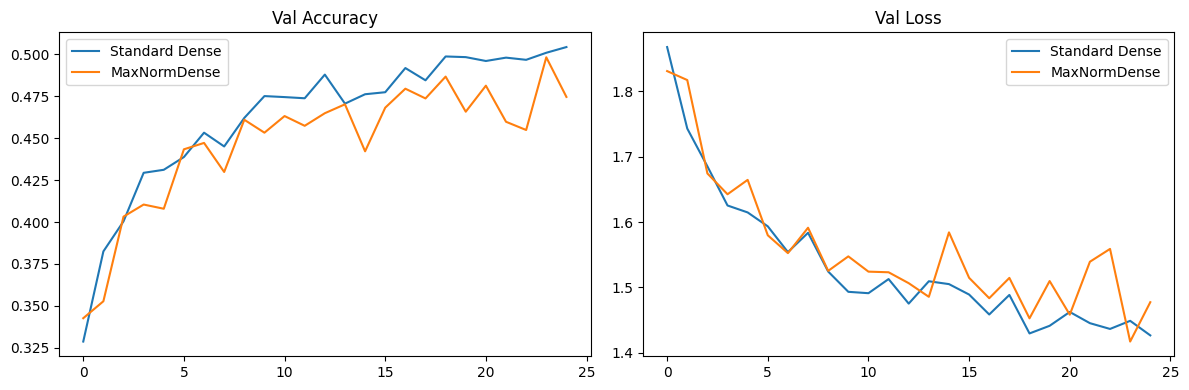

In [2]:
# TF: MaxNormDense — Dense layer with max-norm weight constraint
class MaxNormDense(layers.Layer):
    """Dense layer that clips weight norms to max_norm after each update.
    This prevents any single neuron from having too large incoming weights,
    acting as regularization and improving training stability.
    """
    def __init__(self, units, max_norm=1.0, activation=None, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.max_norm = max_norm
        self.activation = keras.activations.get(activation)

    def build(self, input_shape):
        self.kernel = self.add_weight(
            shape=(input_shape[-1], self.units),
            initializer="glorot_normal", name="kernel"
        )
        self.bias = self.add_weight(
            shape=(self.units,),
            initializer="zeros", name="bias"
        )

    def call(self, inputs):
        # Clip kernel norms — each column (neuron) has norm <= max_norm
        clipped = tf.clip_by_norm(self.kernel, self.max_norm, axes=[0])
        output = tf.matmul(inputs, clipped) + self.bias
        if self.activation:
            output = self.activation(output)
        return output

    def _apply_max_norm(self):
        """Call after optimizer step to actually clip stored weights."""
        self.kernel.assign(tf.clip_by_norm(self.kernel, self.max_norm, axes=[0]))

    def get_config(self):
        config = super().get_config()
        config.update({"units": self.units, "max_norm": self.max_norm,
                       "activation": keras.activations.serialize(self.activation)})
        return config

# Custom callback to apply max-norm constraint after each training step
class MaxNormCallback(keras.callbacks.Callback):
    def on_train_batch_end(self, batch, logs=None):
        for layer in self.model.layers:
            if isinstance(layer, MaxNormDense):
                layer._apply_max_norm()

# Compare: Standard Dense vs MaxNormDense
print("=== Training Standard Dense model ===")
model_std = keras.Sequential([
    layers.Input(shape=(3072,)),
    layers.Dense(256, activation='relu'), layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])
model_std.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
h_std = model_std.fit(X_flat_tr, y_train, epochs=25, batch_size=256, validation_split=0.2, verbose=0)
print(f"Standard Dense best val_acc: {max(h_std.history['val_accuracy']):.4f}")

print("\n=== Training MaxNormDense model ===")
model_mn = keras.Sequential([
    layers.Input(shape=(3072,)),
    MaxNormDense(256, max_norm=1.0, activation='relu'),
    MaxNormDense(128, max_norm=1.0, activation='relu'),
    MaxNormDense(64, max_norm=1.0, activation='relu'),
    layers.Dense(10, activation='softmax')
])
model_mn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
h_mn = model_mn.fit(X_flat_tr, y_train, epochs=25, batch_size=256,
                    validation_split=0.2, verbose=0, callbacks=[MaxNormCallback()])
print(f"MaxNormDense best val_acc: {max(h_mn.history['val_accuracy']):.4f}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(h_std.history['val_accuracy'], label='Standard Dense')
ax[0].plot(h_mn.history['val_accuracy'], label='MaxNormDense')
ax[0].set_title('Val Accuracy'); ax[0].legend()
ax[1].plot(h_std.history['val_loss'], label='Standard Dense')
ax[1].plot(h_mn.history['val_loss'], label='MaxNormDense')
ax[1].set_title('Val Loss'); ax[1].legend()
plt.tight_layout(); plt.show()

In [3]:
# PyTorch: MaxNorm constraint
class MaxNormLinear(nn.Module):
    """Linear layer with max-norm weight constraint applied after each forward pass."""
    def __init__(self, in_features, out_features, max_norm=1.0):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features)
        self.max_norm = max_norm

    def forward(self, x):
        with torch.no_grad():
            norms = self.linear.weight.norm(dim=1, keepdim=True)
            desired = torch.clamp(norms, max=self.max_norm)
            self.linear.weight.data *= desired / (norms + 1e-8)
        return self.linear(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pt_model = nn.Sequential(
    MaxNormLinear(3072, 256), nn.ReLU(),
    MaxNormLinear(256, 128), nn.ReLU(),
    nn.Linear(128, 10)
).to(device)
opt = torch.optim.Adam(pt_model.parameters(), lr=1e-3)
crit = nn.CrossEntropyLoss()
loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(torch.FloatTensor(X_flat_tr), torch.LongTensor(y_train)),
    batch_size=256, shuffle=True)

for ep in range(25):
    pt_model.train()
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad(); crit(pt_model(xb), yb).backward(); opt.step()
pt_model.eval()
with torch.no_grad():
    acc = (pt_model(torch.FloatTensor(X_flat_te).to(device)).argmax(1)==torch.LongTensor(y_test).to(device)).float().mean()
print(f"PyTorch MaxNormLinear Test Acc: {acc:.4f}")

PyTorch MaxNormLinear Test Acc: 0.4951


## Key Takeaways
- MaxNorm constraint clips weight norms after each update
- Prevents weight explosion — especially useful with high learning rates
- Acts as implicit regularization — limits model capacity per neuron
- Can be combined with dropout and batch norm for stronger regularization